In [2]:
x = [5115,864,6296,1285,2342,1163]
y = ["Nov","Nov","Dec","Dec","Jan","Jan",]

In [3]:
import matplotlib.pyplot as plt


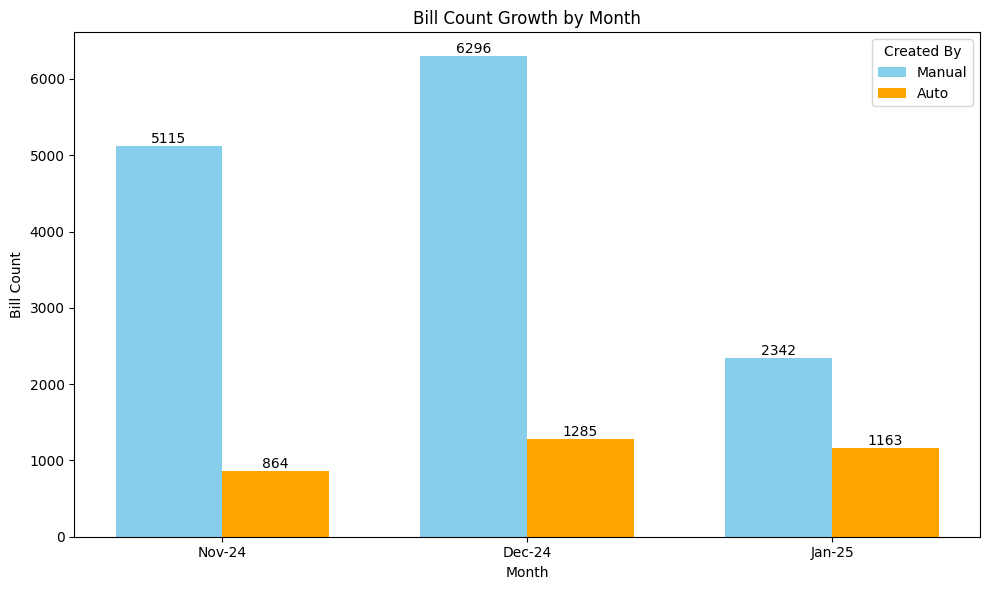

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data
data = {
    "BillCount": [5115, 864, 6296, 1285, 2342, 1163],
    "Month": ["Nov-24", "Nov-24", "Dec-24", "Dec-24", "Jan-25", "Jan-25"],
    "Created By": ["Manual", "Auto", "Manual", "Auto", "Manual", "Auto"],
}
df = pd.DataFrame(data)

# Order the months
df["Month"] = pd.Categorical(df["Month"], categories=["Nov-24", "Dec-24", "Jan-25"], ordered=True)

# Pivot the data for grouped bar plotting
pivot_df = df.pivot(index="Month", columns="Created By", values="BillCount").reset_index()

# Define x positions for the bars
x = np.arange(len(pivot_df["Month"]))  # Number of months
width = 0.35  # Width of the bars

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars for "Manual" and "Auto"
bar1 = ax.bar(x - width / 2, pivot_df["Manual"], width, label="Manual", color="skyblue")
bar2 = ax.bar(x + width / 2, pivot_df["Auto"], width, label="Auto", color="orange")

# Add labels, title, and legend
ax.set_xlabel("Month")
ax.set_ylabel("Bill Count")
ax.set_title("Bill Count Growth by Month")
ax.set_xticks(x)
ax.set_xticklabels(pivot_df["Month"])
ax.legend(title="Created By")

# Add data labels on the bars
for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
